In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,noOfFloor,facing,agePossession,nearbyLocations,furnishDetails,features,area_sqft
0,house,nitin vihar,sector 33,0.85,9444.0,Plot area 900(83.61 sq.m.),3,2,0,not available,1.0,West,1 to 5 Year Old,"['Rajiv Chowk Mosque', 'Airforce Hospital', 'S...",NaN,"['High Ceiling Height', 'Water Storage', 'No o...",900.0
1,flat,shyam sadan,sector 3 phase 2,0.55,6470.0,Carpet area: 700 (65.03 sq.m.),2,2,1,study room,4.0,West,1 to 5 Year Old,"['Sheetla Mata Mandir', 'Chintapurni Mandir', ...","['2 Wardrobe', '1 Water Purifier', '5 Fan', '1...","['Security / Fire Alarm', 'Lift(s)', 'Water pu...",850.0


In [5]:
df[['area_sqft','areaWithType']]

,area_sqft,areaWithType
0,900.0,Plot area 900(83.61 sq.m.)
1,850.0,Carpet area: 700 (65.03 sq.m.)
2,2400.0,Super Built up area 2400(222.97 sq.m.)Built Up...
3,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...
4,602.0,Super Built up area 602(55.93 sq.m.)Built Up a...
5,903.0,Super Built up area 903(83.89 sq.m.)
6,2310.0,Super Built up area 1755(163.04 sq.m.)Built Up...
7,232.0,Plot area 232(21.55 sq.m.)
8,1930.0,Super Built up area 1930(179.3 sq.m.)
9,1000.0,Plot area 1000(92.9 sq.m.)


In [6]:
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float (match.group(1))
    return None
    

In [7]:
def get_area(text,area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
def convert_to_sqft(text,area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m = float(match.group(1))
        return sq_m * 10.7639
    return area_value

In [9]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [ ]:
df.sample(5)

In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area_sqft','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [12]:
df[df['property_type'] == 'house'][['price','property_type','area_sqft','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(860, 7)

In [13]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area_sqft','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [14]:
all_nan_df.shape

(546, 7)

In [15]:
all_nan_df_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area_sqft','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [16]:
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    if match:
        return float(match.group(1))
    return None

In [17]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [18]:
all_nan_df.shape

(546, 7)

In [19]:
def convert_scale(row):
    if np.isnan(row['area_sqft']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area_sqft']/row['built_up_area']) ==  9.0:
            return row['built_up_area'] * 9.0
        elif round(row['area_sqft']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [20]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [ ]:
all_nan_df

In [22]:
df.update(all_nan_df)

In [23]:
df.isna().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
noOfFloor                19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
area_sqft                18
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [24]:
 df.head(2)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,noOfFloor,facing,agePossession,nearbyLocations,furnishDetails,features,area_sqft,super_built_up_area,built_up_area,carpet_area
0,house,nitin vihar,sector 33,0.85,9444.0,Plot area 900(83.61 sq.m.),3,2,0,not available,1.0,West,1 to 5 Year Old,"['Rajiv Chowk Mosque', 'Airforce Hospital', 'S...",NaN,"['High Ceiling Height', 'Water Storage', 'No o...",900.0,NaN,900.0,NaN
1,flat,shyam sadan,sector 3 phase 2,0.55,6470.0,Carpet area: 700 (65.03 sq.m.),2,2,1,study room,4.0,West,1 to 5 Year Old,"['Sheetla Mata Mandir', 'Chintapurni Mandir', ...","['2 Wardrobe', '1 Water Purifier', '5 Fan', '1...","['Security / Fire Alarm', 'Lift(s)', 'Water pu...",850.0,NaN,NaN,700.0


**ADDITIONAL ROOM**

In [25]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [26]:
new_col = ['study room','servant room','pooja room','others','store room']
for col in new_col:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [27]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,noOfFloor,facing,agePossession,nearbyLocations,furnishDetails,features,area_sqft,super_built_up_area,built_up_area,carpet_area,study room,servant room,pooja room,others,store room
1015,flat,paras dews,sector 106,1.35,7297.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,4,3+,"servant room,pooja room",18.0,North-East,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping ...","['4 Fan', '1 Exhaust Fan', '5 Light', '5 AC', ...","['Centrally Air Conditioned', 'Water purifier'...",1850.0,2355.0,2100.0,1850.0,0,1,1,0,0
1891,house,dlf city plots,sector 26,4.00,40775.0,Plot area 109(91.14 sq.m.),4,3,2,not available,2.0,NaN,1 to 5 Year Old,"['Phase 2 Metro Station', 'Grand Mall', 'Jacar...","['7 Fan', '1 Exhaust Fan', '2 Geyser', '10 Lig...",NaN,981.0,NaN,981.0,NaN,0,0,0,0,0
570,flat,microtek greenburg,sector 86,1.45,9797.0,Built Up area: 1480 (137.5 sq.m.)Carpet area: ...,3,2,3,not available,8.0,North-East,1 to 5 Year Old,"['SS Omnia Mall', 'National Highway 8', 'Dwark...","['1 Water Purifier', '5 Fan', '1 Fridge', '1 E...","['Feng Shui / Vaastu Compliant', 'Security / F...",1480.0,NaN,1480.0,1050.0,0,0,0,0,0
2457,house,independent,sector 38,2.10,23333.0,Plot area 100(83.61 sq.m.),7,7,3+,"store room,pooja room,study room",3.0,North-East,1 to 5 Year Old,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Stat...",NaN,"['High Ceiling Height', 'Maintenance Staff', '...",900.0,NaN,900.0,NaN,1,0,1,0,1
3751,flat,vatika the seven lamps,sector 82,0.81,6192.0,Super Built up area 1300(120.77 sq.m.),2,2,2,not available,15.0,West,1 to 5 Year Old,"['SS Omnia Mall', 'Golf Course Ext Rd', 'Knowl...","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1308.0,1300.0,NaN,NaN,0,0,0,0,0


**3.AGE POSSESSION**

In [28]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Dec 2025                 7
Jun 2024                 7
Aug 2023                 7
Nov 2023                 5
Oct 2023                 4
Sep 2023                 4
By 2025                  4
Jul 2024                 4
Aug 2024                 4
May 2024                 3
Feb 2024                 3
Nov 2024                 3
Jan 2025                 3
Jan 2026                 2
Apr 2026                 2
Aug 2025                 2
Dec 2026                 2
Jul 2025                 2
Oct 2025                 2
Jun 2027                 2
Jul 2027                 2
By 2027       

In [29]:
def category_of_age_type(value):
    if pd.isna(value):
        return 'Undefined'
    elif '0 to 1 Year Old' in value or 'Within 3 months' in value or 'Within 6 months' in value:
        return 'New property'
    elif '1 to 5 Year Old' in value:
        return 'Relatively New'
    elif '5 to 10 Year Old' in value:
        return 'Moderately Old'
    elif '10+ Year Old' in value:
        return 'Old property'
    elif 'Under Construction' in value or 'By' in value:
        return 'Under Construction'
    try:
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [30]:
df['agePossession'] = df['agePossession'].apply(category_of_age_type)

In [31]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New property           626
Moderately Old         575
Undefined              333
Old property           310
Under Construction     283
Name: count, dtype: int64

In [32]:
df['agePossession'].isna().sum()

np.int64(0)

In [33]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,noOfFloor,facing,agePossession,nearbyLocations,furnishDetails,features,area_sqft,super_built_up_area,built_up_area,carpet_area,study room,servant room,pooja room,others,store room
1600,flat,tulip violet,sector 69,1.40,8920.0,Super Built up area 1568(145.67 sq.m.),3,3,1,pooja room,12.0,East,Relatively New,"['Airia Mall Sector 68', 'Southern Peripheral ...","['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Power Back-up', 'Feng Shui / Vaastu Complian...",1570.0,1568.0,NaN,NaN,0,0,1,0,0
2651,house,independent,sector 7,0.90,10000.0,Plot area 100(83.61 sq.m.),6,4,3,"servant room,others",3.0,North-East,Old property,"['Dev Man Kathuria Clinic', 'Dr. Madan Clinic'...","['5 Fan', '1 Exhaust Fan', '1 Geyser', '6 Ligh...","['Feng Shui / Vaastu Compliant', 'Water Storag...",900.0,NaN,900.0,NaN,0,1,0,1,0
1244,flat,umang winter hills,sector 77,0.71,5305.0,Super Built up area 1342(124.68 sq.m.)Carpet a...,2,2,2,study room,6.0,North-West,Relatively New,"['Entertainland Mall', 'Delhi Jaipur Expresswa...",NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1338.0,1342.0,NaN,810.0,1,0,0,0,0
1275,flat,godrej oasis,sector 88,2.65,16747.0,Carpet area: 124,3,3,3+,not available,10.0,NaN,New property,"['Double Infinity market', 'Pataudi road', 'Dw...","['1 Exhaust Fan', '1 Stove', '1 Light', '1 AC'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1582.0,NaN,NaN,124.0,0,0,0,0,0
1566,flat,ss the leaf,sector 85,2.10,7467.0,Super Built up area 2812(261.24 sq.m.),4,5,3+,not available,9.0,East,Relatively New,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['4 Wardrobe', '1 Exhaust Fan', '4 Geyser', '4...","['Power Back-up', 'Intercom Facility', 'Lift(s...",2812.0,2812.0,NaN,NaN,0,0,0,0,0


**4.FURNISH DETAIL**

In [ ]:
df['furnishDetails'].value_counts()

In [37]:
#Extract all unique furnishings from the furnishDetails column
all_furnishing = []
for i in df['furnishDetails'].dropna():
    furnishing = i.replace('[','').replace(']','').replace("'","").split(', ')
    all_furnishing.extend(furnishing)
unique_values = list(set(all_furnishing))

#Define a funcion to extract the count of a furnishing from the furnishing detail
def get_furnishing_count(details,furnishing):
    if isinstance(details,str):
        if f'No {furnishing}' in details:
            return 0
        pattern = re.compile(f'(\d+) {furnishing}')
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 

columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_values]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [38]:
furnishings_df.shape

(3803, 19)

In [39]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_38735/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [40]:
furnishings_df.fillna(0,inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_38735/2234713767.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.fillna(0,inplace=True)


In [41]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [43]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

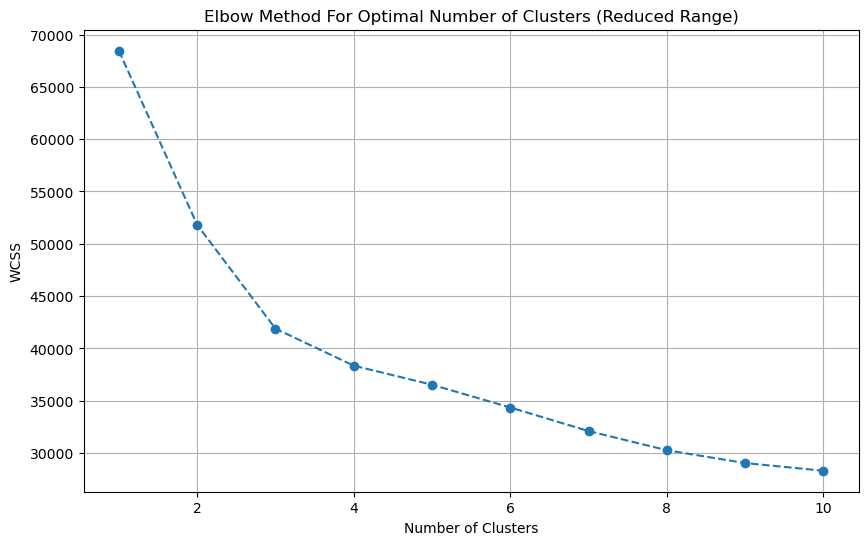

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [70]:
n_clusters = 3
kmeans = KMeans(n_clusters = n_clusters,random_state=42)
kmeans.fit(scaled_data)
cluster_assignments = kmeans.predict(scaled_data)

In [71]:
df = df.iloc[:,:-18]

In [72]:
df['furnishing_type'] = cluster_assignments

In [82]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1211,"['1 Exhaust Fan', '4 Geyser', '1 Stove', '6 AC...",0
1159,"['5 Fan', '1 Exhaust Fan', '2 Geyser', '10 Lig...",0
600,NaN,1
3672,NaN,1
728,NaN,1


**5. FEATURES**

In [46]:
df['features'].isna().sum()

np.int64(635)

In [49]:
df[['society','features']].sample(5)

,society,features
2420,ats triumph,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
875,raheja vedas,NaN
535,smart world orchard,"['Security / Fire Alarm', 'Private Garden / Te..."
3691,ansal housing highland park,"['Intercom Facility', 'Lift(s)', 'Swimming Poo..."
996,signature global solera,"['Power Back-up', 'Security / Fire Alarm', 'In..."


In [54]:
df_appart = pd.read_csv('appartments.csv')

In [55]:
df_appart.head(5)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [59]:
df_appart['PropertyName'] = df_appart['PropertyName'].str.lower()

In [60]:
temp_df = df[df['features'].isnull()]

In [61]:
temp_df.head(2)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,additionalRoom,noOfFloor,facing,agePossession,nearbyLocations,furnishDetails,features,area_sqft,super_built_up_area,built_up_area,carpet_area,study room,servant room,pooja room,others,store room,Fan,TV,Wardrobe,Bed,Geyser,Dining Table,Washing Machine,Chimney,Microwave,Stove,Sofa,Light,Modular Kitchen,Exhaust Fan,Fridge,Water Purifier,Curtains,AC
9,house,cloudnine cottages,sohna road road,5.50,55000.0,Plot area 1000(92.9 sq.m.),3,3,0,not available,1.0,NaN,Moderately Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM...",[],NaN,1000.0,NaN,1000.0,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,house,independent,sector 13,0.62,32291.0,Built Up area: 192 (17.84 sq.m.),6,6,0,not available,3.0,NaN,Undefined,NaN,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,192.0,NaN,192.0,NaN,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
x = temp_df.merge(df_appart,left_on = 'society',right_on = 'PropertyName',how='left')['TopFacilities']

In [66]:
df.loc[temp_df.index,'features'] = x.values

In [67]:
df['features'].isna().sum()

np.int64(481)

In [ ]:
df['features']

In [100]:
all_feature = []
for i in df['features'].dropna():
    if isinstance (i,str):
        feat = i.replace('[','').replace(']','').split(',')
        all_feature.extend(feat)
unique_feat = list(set(all_feature))

In [104]:
len(unique_feat)

167

In [ ]:
unique_feat

In [114]:
unique_feat = [item.replace("'", "").replace('"', "").strip() for item in unique_feat]

In [115]:
unique_feat

['Intercom Facility',
 'Temple',
 'Bar/Chill-Out Lounge',
 'Milk Booth',
 'Car wash area',
 'Basketball Court',
 'CCTV Camera Security',
 'Airy Rooms',
 'Skating Rink',
 'Entrance Lobby',
 'Laundry',
 'Security / Fire Alarm',
 'Sun Deck',
 'Medical Centre',
 'Food Court',
 'Wi-Fi Connectivity',
 'Football',
 'Infinity Pool',
 'Squash Court',
 'Concierge Service',
 'Lift(s)',
 'Shopping Centre',
 'Internet/wi-fi connectivity',
 'Swimming Pool',
 'Shopping Centre',
 'Badminton Court',
 'Terrace Garden',
 '24/7 Water Supply',
 'Spacious Interiors',
 'Power Back-up',
 'Intercom Facility',
 'Restaurant',
 'Water purifier',
 'Video Door Security',
 '24/7 Power Backup',
 'Water Storage',
 'Water Storage',
 'Foosball',
 'Manicured Garden',
 'Party Lawn',
 'Mini Theatre',
 'Property Staff',
 'Car Parking',
 'Flower Garden',
 'RO System',
 'Recently Renovated',
 'Earthquake Resistant',
 'Pool Table',
 'Lounge',
 'Golf Course',
 'Water softening plant',
 'No open drainage around',
 'Doctor on Cal

In [117]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [118]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [119]:
features_binary_df.shape

(3803, 130)

In [123]:
def get_feature_detail(details,feature):
    if isinstance(details,str):
        pattern = feature 
        if pattern in feature:
            return 1
        else:
            return 0
    else:
        return 0

In [124]:
for i in unique_feat:
    df[i] = df['features'].apply(lambda x: get_feature_detail(x,i))

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_38735/1518515800.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i] = df['features'].apply(lambda x: get_feature_detail(x,i))
/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_38735/1518515800.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i] = df['features'].apply(lambda x: get_feature_detail(x,i))
/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_38735/1518515800.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually

In [125]:
furnishings_df = df[['furnishDetails'] + unique_feat]

In [126]:
furnishings_df.head()

,furnishDetails,Intercom Facility,Temple,Bar/Chill-Out Lounge,Milk Booth,Car wash area,Basketball Court,CCTV Camera Security,Airy Rooms,Skating Rink,Entrance Lobby,Laundry,Security / Fire Alarm,Sun Deck,Medical Centre,Food Court,Wi-Fi Connectivity,Football,Infinity Pool,Squash Court,Concierge Service,Lift(s),Shopping Centre,Internet/wi-fi connectivity,Swimming Pool,Shopping Centre,Badminton Court,Terrace Garden,24/7 Water Supply,Spacious Interiors,Power Back-up,Intercom Facility,Restaurant,Water purifier,Video Door Security,24/7 Power Backup,Water Storage,Water Storage,Foosball,Manicured Garden,Party Lawn,Mini Theatre,Property Staff,Car Parking,Flower Garden,RO System,Recently Renovated,Earthquake Resistant,Pool Table,Lounge,Golf Course,Water softening plant,No open drainage around,Doctor on Call,Infinity Pool,Water Softener Plant,Bus Shelter,Vastu Compliant,Security Personnel,Creche/Day care,Centrally Air Conditioned,Private Garden / Terrace,Grocery Shop,Skating Rink,High Ceiling Height,Jacuzzi,Power Back-up,Waste Disposal,Park,Water purifier,Piped-gas,Internal Street Lights,High Ceiling Height,Multipurpose Hall,Feng Shui / Vaastu Compliant,Business Lounge,Amphitheatre,Club house / Community Center,Private Garden / Terrace,Club House,Changing Area,Air Hockey,Natural Light,Cigar Lounge,Billiards,Security Personnel,Volley Ball Court,Reflexology Park,Power Back up Lift,Clinic,Card Room,Steam Room,Community Hall,False Ceiling Lighting,No open drainage around,Rain Water Harvesting,Separate entry for servant room,Centrally Air Conditioned,Sewage Treatment Plant,Food Court,Cafeteria,Gymnasium,Park,Lift(s),Internet/wi-fi connectivity,Security / Fire Alarm,Spa,Fountain,Feng Shui / Vaastu Compliant,Bank Attached Property,Childrens Play Area,Gazebo,Visitors Parking,Visitor Parking,Bowling Alley,Sauna,School,Doctor on Call,Salon,Lawn Tennis Court,Landscape Garden,Salon,Fitness Centre / GYM,Waste Disposal,Automated Car Wash,Theatre,Solar Water Heating,Visitor Parking,Solar Lighting,24x7 Security,Natural Pond,Piped Gas,Low Density Society,Maintenance Staff,Cricket Pitch,Conference room,Valet Parking,Club house / Community Center,Bus Shelter,Library,Multipurpose Court,Barbecue,Waiting Lounge,High Speed Elevators,Piped-gas,School,Concierge Service,Jogging Track,Swimming Pool,Natural Pond,Manicured Garden,Aerobics Centre,Banquet Hall,Jogging Track,False Ceiling Lighting,Yoga/Meditation Area,Fitness Centre / GYM,Fire Fighting Systems,ATM,Mini Theatre,Gated Community,Lounge,Toddler Pool,Reading Lounge,Maintenance Staff,Beach Volley Ball Court,Natural Light,Pergola
0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,"['2 Wardrobe', '1 Water Purifier', '5 Fan', '1...",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,"['5 Fan', '1 Exhaust Fan', '3 Geyser', '25 Lig...",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1